# 🏠 Predicción de Precios de Viviendas con Redes Neuronales

**Caso de Estudio** — Firma de inversión inmobiliaria

**Objetivo:** Modelo RNA para predecir precios. Métricas: RMSE < 15% precio medio, R² > 0.60

**Dataset:** [Housing Prices (Kaggle)](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)


## 0. Instalación de dependencias

Aquí se instalan y cargan todas las herramientas necesarias.

Se usa pandas y numpy para manipular los datos.

In [2]:
# Ejecutar solo la primera vez
!pip install tensorflow numpy pandas scikit-learn matplotlib seaborn kagglehub



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importar librerías

matplotlib y seaborn para dibujar gráficas.
scikit-learn para preprocesar los datos y comparar con modelos básicos.
tensorflow y keras para construir y entrenar la red neuronal.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow: {tf.__version__}')


TensorFlow: 2.21.0


## 2. Carga del Dataset

Descargamos el dataset de Kaggle con `kagglehub`.

Descarga automáticamente la base de datos de viviendas desde Kaggle utilizando la librería kagglehub. Si esto falla por cualquier motivo, tiene un plan B que intenta leer un archivo local llamado Housing.csv. Tras esto, muestra que el dataset tiene varias columnas (variables) y filas (ejemplos de casas).

In [4]:
# Descarga automática desde Kaggle
try:
    import kagglehub, os
    path = kagglehub.dataset_download('yasserh/housing-prices-dataset')
    df = pd.read_csv(os.path.join(path, 'Housing.csv'))
    print('Dataset cargado desde kagglehub')
except Exception as e:
    print(f'kagglehub falló: {e}')
    print('Descarga Housing.csv manualmente y ponlo en esta carpeta')
    df = pd.read_csv('Housing.csv')

print(f'Dimensiones: {df.shape}')
df.head()


100%|██████████| 4.63k/4.63k [00:00<00:00, 5.27MB/s]

Extracting files...
Dataset cargado desde kagglehub
Dimensiones: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## 3. Exploración Inicial

Exploración: Se revisa qué tipo de dato tiene cada columna y si hay datos en blanco o valores nulos.

In [5]:
print(df.info())
print('\nEstadísticas:')
display(df.describe())
print(f'\nValores nulos: {df.isnull().sum().sum()}')


<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB
None

Estadísticas:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000



Valores nulos: 0


## 4. Visualización de Distribuciones

Histogramas: Muestran cómo se distribuyen los precios, áreas de las casas, nº de habitaciones, etc.

Boxplots (Diagramas de caja): Son muy útiles para detectar valores atípicos (outliers). Por ejemplo, si hay una mansión que vale 10 veces más que el resto, el boxplot lo evidenciará.

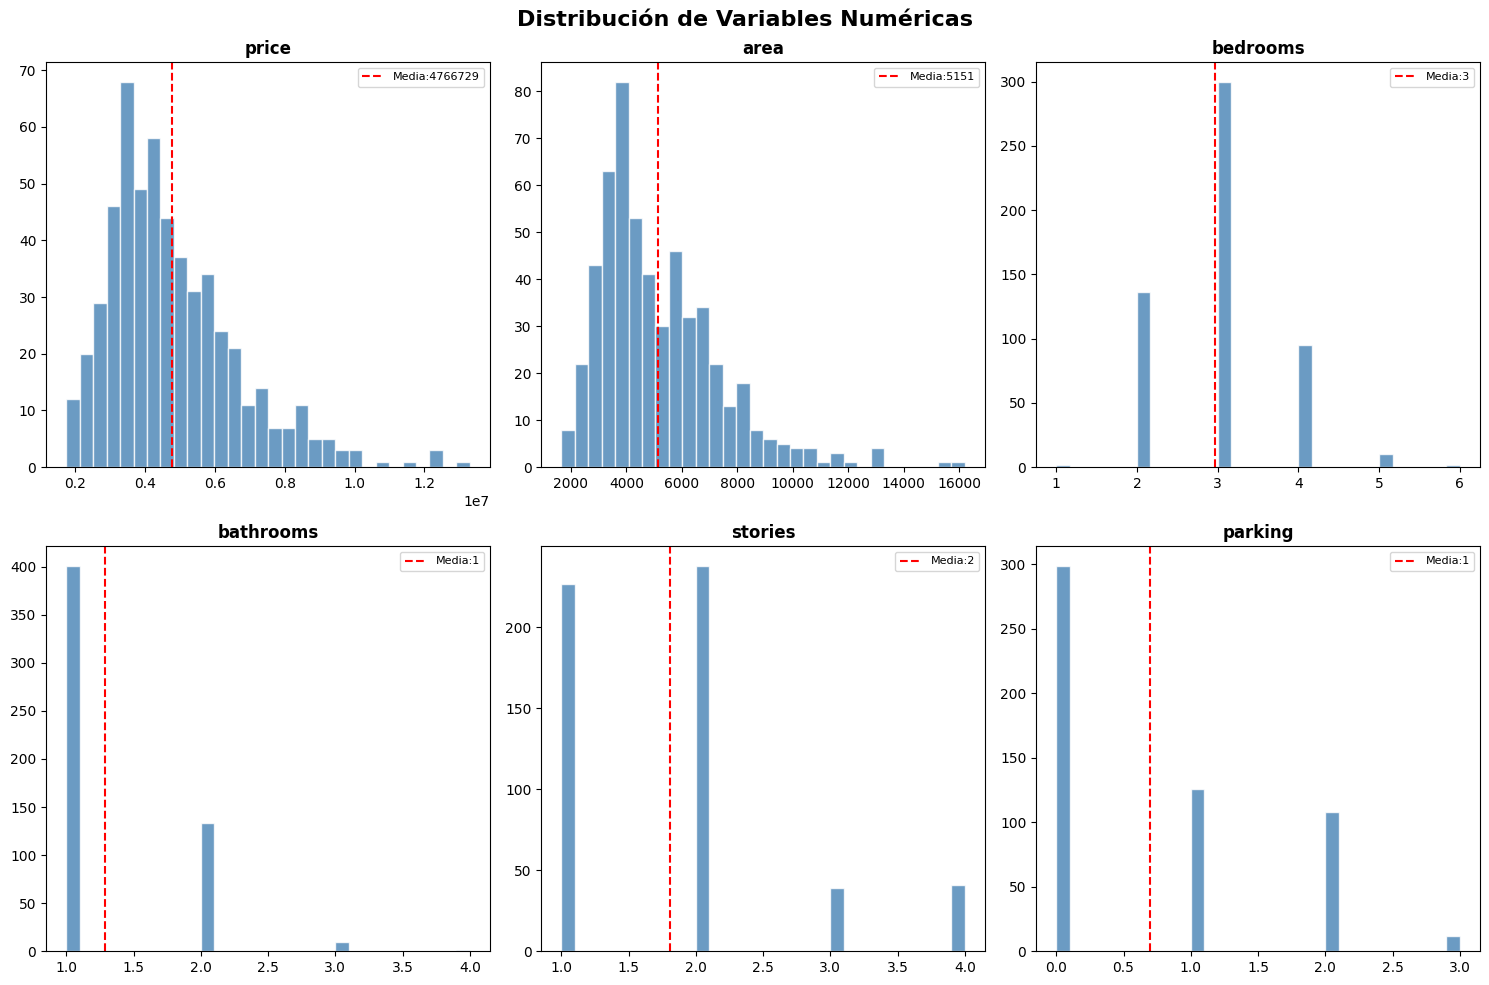

In [6]:
# Histogramas
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16, fontweight='bold')
for i, col in enumerate(['price','area','bedrooms','bathrooms','stories','parking']):
    ax = axes[i//3, i%3]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontweight='bold')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Media:{df[col].mean():.0f}')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


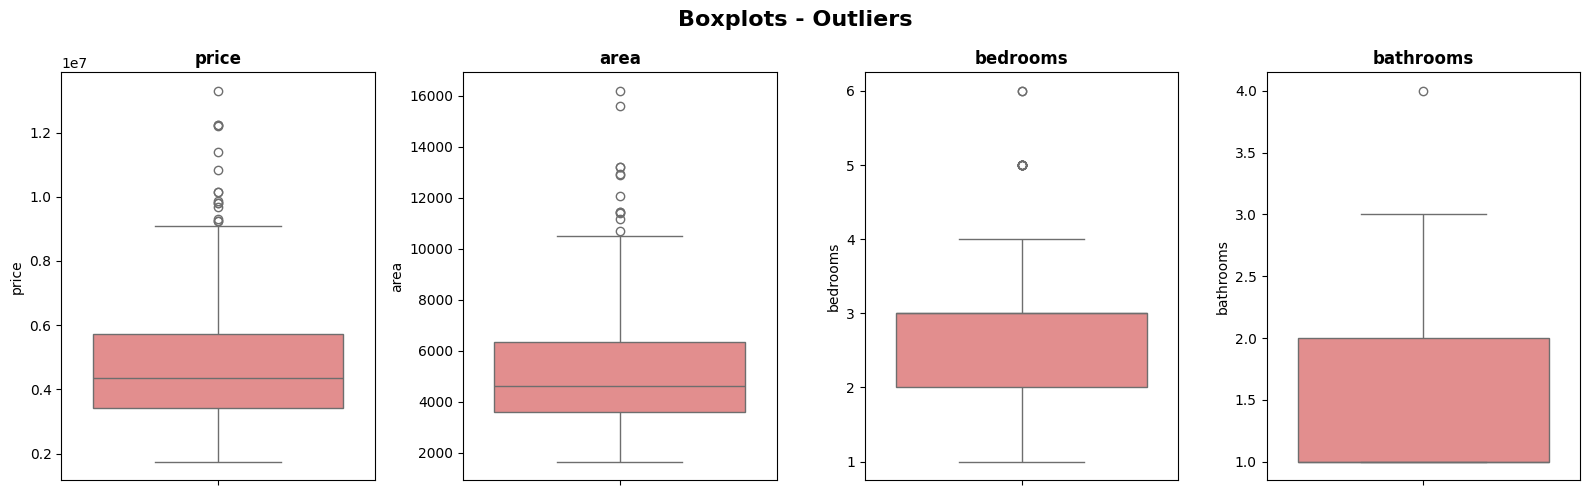

In [7]:
# Boxplots
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Boxplots - Outliers', fontsize=16, fontweight='bold')
for i, col in enumerate(['price','area','bedrooms','bathrooms']):
    sns.boxplot(data=df, y=col, ax=axes[i], color='lightcoral')
    axes[i].set_title(col, fontweight='bold')
plt.tight_layout(); plt.show()


## 5. Análisis de Correlación

Calcula e imprime una Matriz de Correlación, que muestra la relación matemática entre todas las variables. Lo más importante aquí es ver qué variables están más correlacionadas con el price (precio), es decir, qué factores (como el área, número de baños o tener aire acondicionado) hacen que una casa sea más cara.

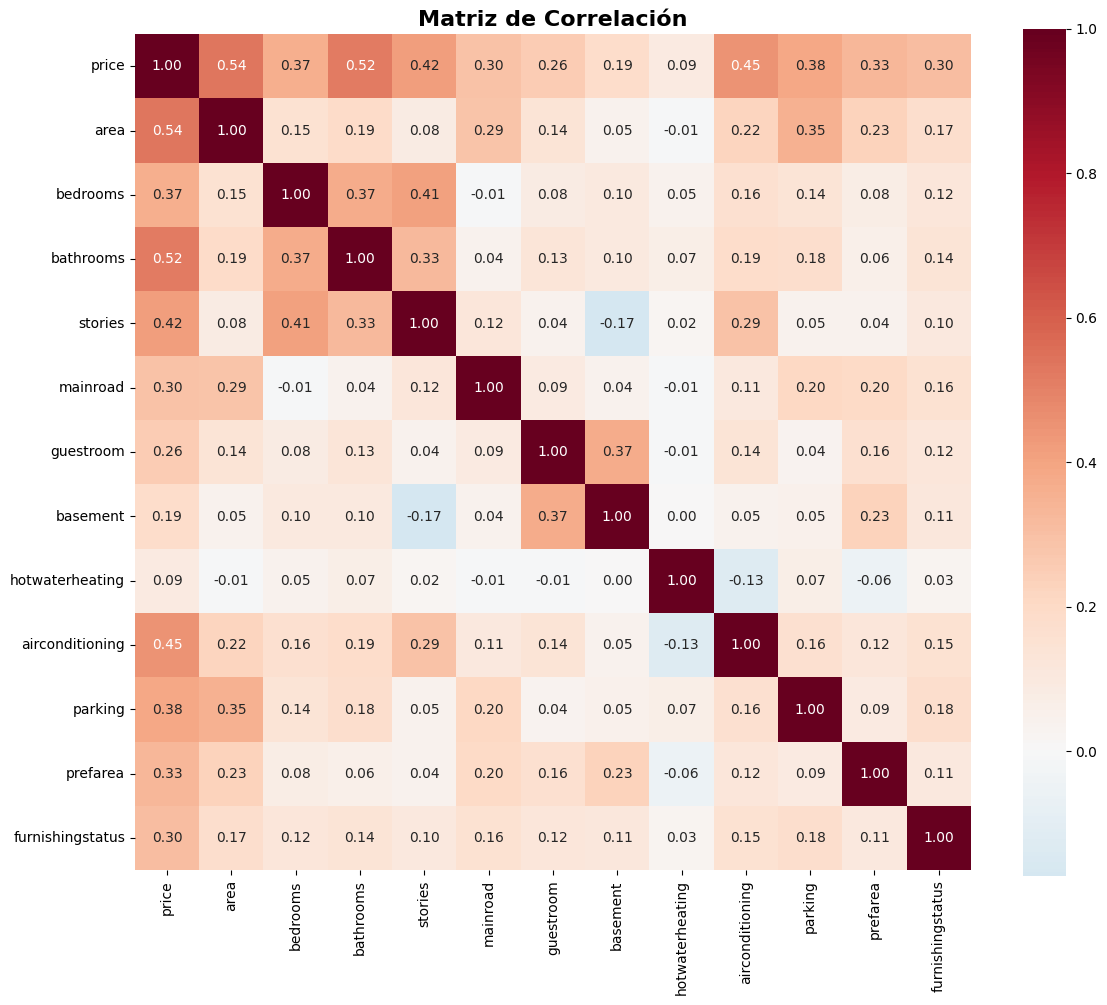

Correlación con price:
area                0.535997
bathrooms           0.517545
airconditioning     0.452954
stories             0.420712
parking             0.384394
bedrooms            0.366494
prefarea            0.329777
furnishingstatus    0.304721
mainroad            0.296898
guestroom           0.255517
basement            0.187057
hotwaterheating     0.093073
Name: price, dtype: float64


In [8]:
# Codificación temporal para correlación
df_c = df.copy()
for c in ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']:
    df_c[c] = df_c[c].map({'yes':1,'no':0})
df_c['furnishingstatus'] = df_c['furnishingstatus'].map({'unfurnished':0,'semi-furnished':1,'furnished':2})

plt.figure(figsize=(12,10))
corr = df_c.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Matriz de Correlación', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

print('Correlación con price:')
print(corr['price'].drop('price').sort_values(ascending=False))


## 6. Preprocesamiento

Las redes neuronales solo entienden números, no texto. En este paso:

Se rellenan los datos faltantes (nulos) usando valores medios o más frecuentes.

Se cambian columnas de texto binarias como "yes"/"no" por 1 y 0.

Se aplica One-hot encoding a variables con múltiples categorías (como el estado de los muebles: furnishingstatus). Esto crea nuevas columnas numéricas para cada categoría.

In [9]:
# Imputar nulos
for c in df.select_dtypes(include=[np.number]).columns:
    if df[c].isnull().sum()>0: df[c].fillna(df[c].median(), inplace=True)
for c in df.select_dtypes(include=['object']).columns:
    if df[c].isnull().sum()>0: df[c].fillna(df[c].mode()[0], inplace=True)

# Codificar binarias
for c in ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']:
    df[c] = df[c].map({'yes':1,'no':0})

# One-hot encoding
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True, dtype=int)
print(f'Columnas: {df.columns.tolist()}')
df.head()


Columnas: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


## 7. Split Train/Test (80/20) y Normalización

Split (División): Se separan los datos. Un 80% de las casas se usará para que el modelo aprenda (Train) y el 20% restante se ocultará para examinarlo después (Test).

Normalización: Se utiliza StandardScaler para que todas las variables tengan una escala similar (media 0 y varianza 1). Esto ayuda a que la red neuronal aprenda mucho más rápido y de manera estable.

In [10]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

# Normalización (fit solo en train)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print('Normalización aplicada')


Train: 436, Test: 109
Normalización aplicada


## 8. Arquitectura de la Red Neuronal

Entrada: Todas las características normalizadas de la casa.

Capas ocultas: Dos capas (de 64 y 32 neuronas) con activación ReLU. Se incluye Dropout y regularización L2 para evitar que la red "memorice" los datos de entrenamiento (fenómeno llamado overfitting).

Salida: Una única neurona que predice un número lineal (el precio).

In [11]:
n_feat = X_train_s.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_feat,)),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(1, activation='linear')
], name='modelo_precios')

model.summary()


Model: "modelo_precios"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Compilar Modelo

Compilación: Se elige cómo va a aprender la red. Se usa el optimizador Adam y se busca minimizar el MSE (Error Cuadrático Medio).

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
print('Modelo compilado')


Modelo compilado


## 10. Entrenamiento

Se entrena la red dándole los datos de Train durante un máximo de 100 épocas (pasadas).

Se utilizan "Callbacks" muy útiles: EarlyStopping (detiene el entrenamiento si la IA deja de mejorar para ahorrar tiempo) y ReduceLROnPlateau (reduce el ritmo de aprendizaje si la red se atasca, para que busque la solución con más cuidado).

In [13]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
rlr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train_s, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[es, rlr],
    verbose=1
)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 25349387714560.0000 - mae: 4727422.5000 - val_loss: 24781596393472.0000 - val_mae: 4623897.5000 - learning_rate: 0.0010
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349383520256.0000 - mae: 4727422.0000 - val_loss: 24781592199168.0000 - val_mae: 4623896.5000 - learning_rate: 0.0010
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349379325952.0000 - mae: 4727420.5000 - val_loss: 24781583810560.0000 - val_mae: 4623896.0000 - learning_rate: 0.0010
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349366743040.0000 - mae: 4727419.5000 - val_loss: 24781573324800.0000 - val_mae: 4623894.5000 - learning_rate: 0.0010
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349356257280.0000 - mae: 4727419.0000 - val_loss: 24781558644736.0000 - val_mae: 4623893.5000 - learning_rate: 0.0010
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25349339480064.0000 - mae: 4727416.5000 - val

## 11. Curvas de Entrenamiento

Por último, muestra unas gráficas para ver si el error fue disminuyendo a medida que pasaba el tiempo de entrenamiento.

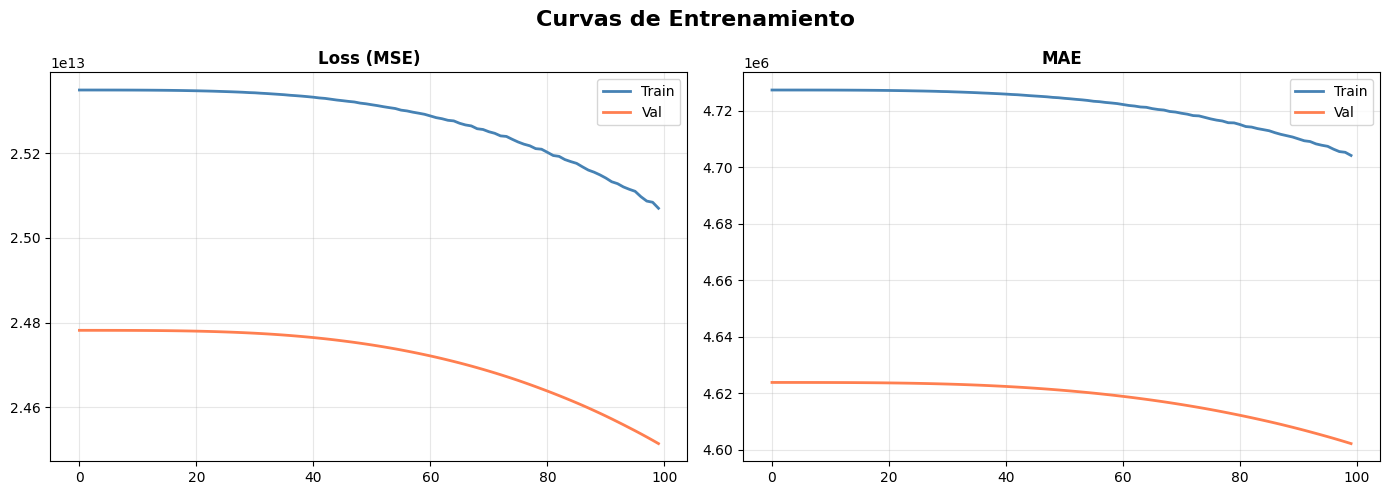

In [14]:
fig, ax = plt.subplots(1,2,figsize=(14,5))
ax[0].plot(history.history['loss'],label='Train',color='steelblue',lw=2)
ax[0].plot(history.history['val_loss'],label='Val',color='coral',lw=2)
ax[0].set_title('Loss (MSE)',fontweight='bold'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history.history['mae'],label='Train',color='steelblue',lw=2)
ax[1].plot(history.history['val_mae'],label='Val',color='coral',lw=2)
ax[1].set_title('MAE',fontweight='bold'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.suptitle('Curvas de Entrenamiento',fontsize=16,fontweight='bold')
plt.tight_layout(); plt.show()


## 12. Experimento: SGD con Momentum

Es una prueba donde se crea una red neuronal idéntica a la anterior, pero usando un optimizador clásico llamado SGD (con Momentum) en lugar de Adam. Sirve simplemente para comparar cuál algoritmo de aprendizaje funciona mejor para este problema.

In [15]:
model_sgd = keras.Sequential([
    layers.Input(shape=(n_feat,)),
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.2),
    layers.Dense(1, activation='linear')
])
model_sgd.compile(optimizer=keras.optimizers.SGD(learning_rate=0.001,momentum=0.9), loss='mse', metrics=['mae'])
model_sgd.fit(X_train_s, y_train, validation_split=0.2, epochs=100, batch_size=32,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)], verbose=0)
print('SGD entrenado')


SGD entrenado


## 13. Evaluación en Test

Se calcula el RMSE (el error promedio en dinero real) y el R² (cuánta varianza del precio logramos explicar; el ideal es 1.0).

In [16]:
yp_adam = model.predict(X_test_s, verbose=0).flatten()
yp_sgd = model_sgd.predict(X_test_s, verbose=0).flatten()

rmse_a = np.sqrt(mean_squared_error(y_test, yp_adam))
r2_a = r2_score(y_test, yp_adam)
rmse_s = np.sqrt(mean_squared_error(y_test, yp_sgd))
r2_s = r2_score(y_test, yp_sgd)
umbral = 0.15 * y_test.mean()

print(f'         Adam         SGD')
print(f'RMSE  {rmse_a:>10,.0f}  {rmse_s:>10,.0f}')
print(f'R²    {r2_a:>10.4f}  {r2_s:>10.4f}')
print(f'\nUmbral RMSE (15%): {umbral:,.0f}')
print(f'Adam RMSE ok: {rmse_a < umbral}')
print(f'Adam R² > 0.60: {r2_a > 0.6}')


         Adam         SGD
RMSE   5,459,067  3,089,878,901,601
R²       -4.8959  -1888855261184.0000

Umbral RMSE (15%): 751,131
Adam RMSE ok: False
Adam R² > 0.60: False


## 14. Gráficos de Evaluación

Se muestran gráficos que comparan el precio predicho vs. el precio real. Cuanto más se acerquen los puntos a la línea diagonal perfecta, mejor es el modelo.

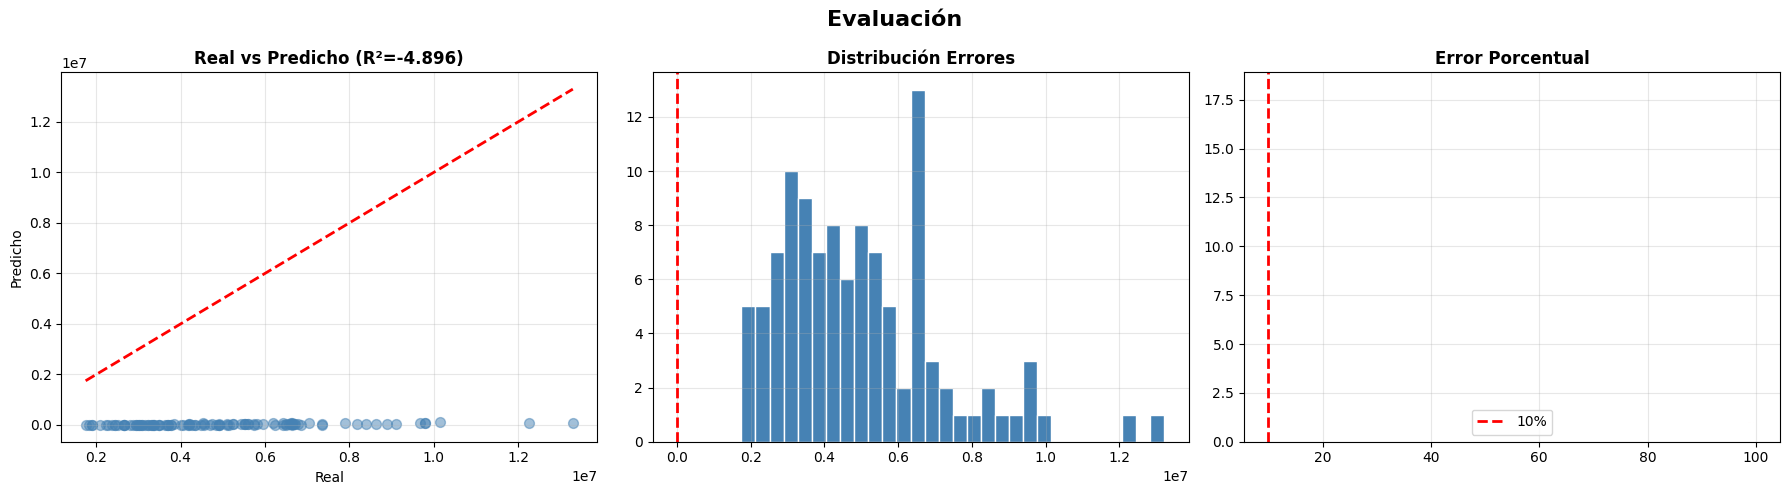

In [17]:
fig, ax = plt.subplots(1,3,figsize=(18,5))

ax[0].scatter(y_test, yp_adam, alpha=0.5, color='steelblue', s=50)
ax[0].plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2)
ax[0].set_xlabel('Real'); ax[0].set_ylabel('Predicho')
ax[0].set_title(f'Real vs Predicho (R²={r2_a:.3f})',fontweight='bold')
ax[0].grid(alpha=0.3)

err = y_test.values - yp_adam
ax[1].hist(err, bins=30, color='steelblue', edgecolor='white')
ax[1].axvline(0, color='red', linestyle='--', lw=2)
ax[1].set_title('Distribución Errores',fontweight='bold'); ax[1].grid(alpha=0.3)

err_pct = np.abs(err/y_test.values)*100
ax[2].hist(err_pct, bins=30, color='coral', edgecolor='white')
ax[2].axvline(10, color='red', linestyle='--', lw=2, label='10%')
ax[2].set_title('Error Porcentual',fontweight='bold'); ax[2].legend(); ax[2].grid(alpha=0.3)

plt.suptitle('Evaluación',fontsize=16,fontweight='bold')
plt.tight_layout(); plt.show()


## 15. Errores Significativos (>10%)

Filtra y muestra una tabla con aquellas casas donde la red se equivocó por más de un 10%. Es un paso analítico útil para entender en qué tipo de casas falla nuestro modelo (por ejemplo, tal vez se equivoca mucho con las casas excesivamente caras).

In [18]:
mask = err_pct > 10
print(f'Con error>10%: {mask.sum()} de {len(y_test)} ({mask.sum()/len(y_test)*100:.1f}%)')
if mask.sum()>0:
    he = pd.DataFrame({'Real':y_test.values[mask],'Pred':yp_adam[mask],'Err%':err_pct[mask].round(1)})
    display(he.sort_values('Err%',ascending=False).head(10))


Con error>10%: 109 de 109 (100.0%)


,Real,Pred,Err%
5,4900000,2163.714844,100.0
79,2233000,937.478333,100.0
105,3773000,1600.160156,100.0
70,3640000,1712.126221,100.0
45,4480000,2004.006592,100.0
12,3360000,2550.859619,99.9
9,3353000,4505.432617,99.9
11,2660000,3408.224854,99.9
26,3080000,4187.247559,99.9
2,3710000,5223.602539,99.9


## 16. Comparación con Baseline (Regresión Lineal)

Se entrena un modelo matemático muy simple y tradicional (Regresión Lineal) y se compara con nuestra Red Neuronal. El objetivo de este paso es justificar que usar Deep Learning realmente aportó valor respecto a fórmulas matemáticas básicas.

In [19]:
lr = LinearRegression().fit(X_train_s, y_train)
yp_lr = lr.predict(X_test_s)
rmse_lr = np.sqrt(mean_squared_error(y_test, yp_lr))
r2_lr = r2_score(y_test, yp_lr)

print(f'         RNA      Reg.Lin.')
print(f'RMSE  {rmse_a:>9,.0f}  {rmse_lr:>9,.0f}')
print(f'R²    {r2_a:>9.4f}  {r2_lr:>9.4f}')
if r2_a > r2_lr:
    print(f'RNA supera a Reg.Lineal en R² por {r2_a-r2_lr:.4f}')


         RNA      Reg.Lin.
RMSE  5,459,067  1,324,507
R²      -4.8959     0.6529


## 17. Validación Cruzada K-Fold (k=5)

La validación cruzada es una técnica avanzada para asegurarse de que el resultado no fue "suerte". En lugar de hacer una sola división de Train/Test del 80/20, hace este proceso 5 veces con divisiones distintas y saca la nota media.

In [20]:
X_all = scaler.fit_transform(X)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
sc = []
for fold,(ti,vi) in enumerate(kf.split(X_all)):
    m = keras.Sequential([
        layers.Input(shape=(n_feat,)),
        layers.Dense(64,activation='relu',kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.2),
        layers.Dense(32,activation='relu',kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.2),
        layers.Dense(1,activation='linear')])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),loss='mse')
    m.fit(X_all[ti],y.values[ti],epochs=100,batch_size=32,
        validation_data=(X_all[vi],y.values[vi]),
        callbacks=[callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)],verbose=0)
    r2=r2_score(y.values[vi],m.predict(X_all[vi],verbose=0).flatten())
    sc.append(r2)
    print(f'Fold {fold+1}: R²={r2:.4f}')
print(f'\nMedia R²: {np.mean(sc):.4f} (±{np.std(sc):.4f})')


Fold 1: R²=-4.8350
Fold 2: R²=-5.8066
Fold 3: R²=-11.9005
Fold 4: R²=-7.6971
Fold 5: R²=-6.0658

Media R²: -7.2610 (±2.4958)


## 18. Guardar Modelo

El modelo entrenado se guarda en el disco duro como modelo_precios_viviendas.keras para poder utilizarlo en el futuro en una app o web sin tener que volver a entrenarlo.

In [21]:
model.save('modelo_precios_viviendas.keras')
print('Modelo guardado')
m2 = keras.models.load_model('modelo_precios_viviendas.keras')
print(f'Verificación: {m2.predict(X_test_s[:3],verbose=0).flatten()}')


Modelo guardado
Verificación: [ 4046.0452 54727.72    5223.6025]


## 19. Resumen Final

Finalmente, imprime un bloque de texto resumiendo todas las métricas de éxito (RMSE, R², superación del Baseline) para presentar rápidamente los resultados.

In [22]:
print(f'''\n
RESUMEN FINAL\n
{'='*50}\n
Arquitectura: {n_feat} → 64(ReLU) → 32(ReLU) → 1(Linear)\n
Optimizador: Adam (lr=0.001), Loss: MSE\n
\n
Test:  RMSE={rmse_a:,.0f} (umbral:{umbral:,.0f})  R²={r2_a:.4f}\n
KFold: R² medio={np.mean(sc):.4f}\n
vs LR: RNA R²={r2_a:.4f} vs LR R²={r2_lr:.4f}\n
''')




RESUMEN FINAL


Arquitectura: 13 → 64(ReLU) → 32(ReLU) → 1(Linear)

Optimizador: Adam (lr=0.001), Loss: MSE



Test:  RMSE=5,459,067 (umbral:751,131)  R²=-4.8959

KFold: R² medio=-7.2610

vs LR: RNA R²=-4.8959 vs LR R²=0.6529


